<a href="https://colab.research.google.com/github/praffuln/agentic-ai/blob/master/checkpointers%20/sqlite3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph-checkpoint-sqlite langchain_core langgraph langchain_openai

In [ ]:
%%capture --no-stderr;
%pip install -U langchain_community tiktoken langchainhub scikit-learn langchain langgraph tavily-python  nomic[local] langchain-nomic google-generativeai langchain_google_genai

In [ ]:
import sqlite3
# In memory
conn = sqlite3.connect(":memory:", check_same_thread = False)

In [ ]:
# pull file if it doesn't exist and connect to local db
# !mkdir -p state_db && [ ! -f state_db/example.db ] && wget -P state_db https://github.com/langchain-ai/langchain-academy/raw/main/module-2/state_db/example.db

db_path = "state_db/example.db"
conn = sqlite3.connect(db_path, check_same_thread=False)

--2025-05-01 10:06:20--  https://github.com/langchain-ai/langchain-academy/raw/main/module-2/state_db/example.db
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/langchain-ai/langchain-academy/main/module-2/state_db/example.db [following]
--2025-05-01 10:06:21--  https://raw.githubusercontent.com/langchain-ai/langchain-academy/main/module-2/state_db/example.db
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 110592 (108K) [application/octet-stream]
Saving to: ‘state_db/example.db’

example.db          100%[===================>] 108.00K  --.-KB/s    in 0.02s   

2025-05-01 10:06:21 (4.23 MB/s) - ‘s

In [ ]:
# Here is our checkpointer
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

## Setup Keys

In [8]:
from google.colab import userdata


In [9]:
# Assigning value to variable
# Assigning value to variable
GEMINI_API_KEY=userdata.get('GEMINI_API_KEY')
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
LANGCHAIN_API_KEY = userdata.get('LANGCHAIN_API_KEY')



In [11]:
import os
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.vectorstores import FAISS

os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = LANGCHAIN_API_KEY
os.environ['GOOGLE_API_KEY'] = GEMINI_API_KEY
os.environ['TAVILY_API_KEY'] = GEMINI_API_KEY

In [12]:
# LLM with function call
model = ChatGoogleGenerativeAI(model="gemini-1.5-flash", temperature=0.3) # Try using gemini-pro-vision
# Create embeddings using a Google Generative AI model
embedding = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

model.invoke('When is diwali ?')

AIMessage(content='Diwali is celebrated on a different date each year, as it falls on the 15th day of the Kartik month in the Hindu lunisolar calendar.  Therefore, there\'s no single fixed date in the Gregorian calendar.  To know the exact date for a particular year, you\'ll need to search online for "Diwali 2024" (or whichever year you\'re interested in).', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-7b5faaac-31fe-463d-bb50-182401e86e7f-0', usage_metadata={'input_tokens': 5, 'output_tokens': 88, 'total_tokens': 93, 'input_token_details': {'cache_read': 0}})

In [25]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

from langgraph.graph import END
from langgraph.graph import MessagesState


class State(MessagesState):
    summary: str


# Define the logic to call the model
def device_summary(state: State):



      # Add summary to system message
      system_message = f"Summary of device passed from state you can check wikipedia :"

      # Append summary to any newer messages
      messages = [SystemMessage(content=system_message)] + state["messages"]

      response = model.invoke(messages)
      return {"messages": response}



# Define the logic to call the model
def call_model(state: State):

    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:

        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]

    else:
        messages = state["messages"]

    response = model.invoke(messages)
    return {"messages": response}

def summarize_conversation(state: State):

    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt
    if summary:

        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )

    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)

    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State):

    """Return the next node to execute."""

    messages = state["messages"]

    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"

    # Otherwise we can just end
    return END

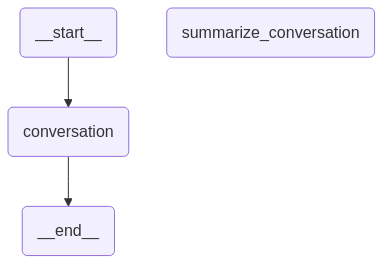

In [26]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", device_summary)
workflow.add_node("summarize_conversation", summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm from schneider")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="from which company I am ?")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="i like to search on se.com about red switch")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hi!  It's nice to meet you.  Are you referring to Schneider Electric, or is Schneider a location?  Knowing that would help me understand better.
================================== Ai Message ==================================

You haven't told me which company you're from.  You said you're "from Schneider," which I assume means Schneider Electric, but I need confirmation.
================================== Ai Message ==================================

se.com is the website for Schneider Electric.  To find information about "red switches" on their site, I recommend using their search function.  You can also try searching for more specific terms, such as the type of switch (e.g., "red push button switch," "red limit switch," "red toggle switch"), or the product line if you know it.  Being more specific in your search terms will likely yield better results.


In [28]:
config = {"configurable": {"thread_id": "1"}}
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content="hi! I'm from schneider", additional_kwargs={}, response_metadata={}, id='bbb657ea-d2c5-4f2f-8c42-19f5536b2de1'), AIMessage(content="Hi!  It's nice to meet you.  Are you referring to Schneider Electric, or is Schneider a location?  Knowing that would help me understand better.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-8b4a0aa7-49d7-435e-ac3a-d428dec92f94-0', usage_metadata={'input_tokens': 141, 'output_tokens': 35, 'total_tokens': 176, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='from which company I am ?', additional_kwargs={}, response_metadata={}, id='af6d95e4-dbd2-4b00-88ac-131f3ca26914'), AIMessage(content='You haven\'t told me which company you\'re from.  You said you\'re "from Schneider," which I assume means Schneider Electric, but I need confirmation.', additional_kwargs={}, response_

## To Test the Persistant Graph State Restart the Session or Notebook or System

In [29]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content="hi! I'm from schneider", additional_kwargs={}, response_metadata={}, id='bbb657ea-d2c5-4f2f-8c42-19f5536b2de1'), AIMessage(content="Hi!  It's nice to meet you.  Are you referring to Schneider Electric, or is Schneider a location?  Knowing that would help me understand better.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-8b4a0aa7-49d7-435e-ac3a-d428dec92f94-0', usage_metadata={'input_tokens': 141, 'output_tokens': 35, 'total_tokens': 176, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='from which company I am ?', additional_kwargs={}, response_metadata={}, id='af6d95e4-dbd2-4b00-88ac-131f3ca26914'), AIMessage(content='You haven\'t told me which company you\'re from.  You said you\'re "from Schneider," which I assume means Schneider Electric, but I need confirmation.', additional_kwargs={}, response_